 # Deep Learning - Assignment 2
 ## Siamese Networks for One-Shot Facial Recognition

 **Student Names:** Yuriy Rusanov, Elad Orpaz

 **ID(s):** 340915149, 206216517

## 1. Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import init
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time
from sklearn.model_selection import train_test_split

In [2]:
# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.5.1
CUDA Available: True


## 2. Configuration

In [3]:
# --- Dataset Configuration ---
DATA_DIR = 'data/lfw2'  # directory of the LFW dataset images
TRAIN_PAIRS_FILE = 'data/pairsDevTrain.txt'
TEST_PAIRS_FILE = 'data/pairsDevTest.txt'

# --- Image Preprocessing ---
IMG_SIZE = (105, 105)

# --- Dataset Configuration ---
VAL_SPLIT_RATIO = 0.2
BATCH_SIZE = 64

# --- Device Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Dataset Parsing and Loading

 ### 3.1. Parse Pairs Files
 We need a function to read the `pairsDevTrain.txt` and `pairsDevTest.txt` files. These files have two formats:
 1.  **Positive Pairs:** `person_name\timg_num1\timg_num2` (Images of the same person)
 2.  **Negative Pairs:** `person_name1\timg_num1\tperson_name2\timg_num2` (Images of different people)

 We'll create pairs of image paths and a label (1 for same person, 0 for different).

In [4]:
def parse_pairs_file(file_path, data_dir):
    """
    Parses the LFW pairs file and returns a list of image pairs and labels.

    Args:
        file_path (str): Path to the pairs file (e.g., pairsDevTrain.txt).
        data_dir (str): Path to the directory containing LFW images.

    Returns:
        list: A list of tuples, where each tuple is ((img1_path, img2_path), label).
              label is 1 for a match (same person) and 0 for a mismatch.
    """
    pairs = []
    with open(file_path, 'r') as f:
        lines = f.readlines()
        num_pairs_info = int(lines[0].strip())  # First line contains the number of pairs of each type

        # Process lines for positive pairs (same person)
        for i in range(1, num_pairs_info + 1):
            line = lines[i].strip().split('\t')
            person_name = line[0]
            img_num1 = int(line[1])
            img_num2 = int(line[2])

            img1_path = os.path.join(data_dir, person_name, f"{person_name}_{img_num1:04d}.jpg")
            img2_path = os.path.join(data_dir, person_name, f"{person_name}_{img_num2:04d}.jpg")

            if os.path.exists(img1_path) and os.path.exists(img2_path):
                pairs.append(((img1_path, img2_path), 1))
            else:
                print(f"Warning: Image path not found for positive pair: {line}")

        # Process lines for negative pairs (different people)
        for i in range(num_pairs_info + 1, len(lines)):
            line = lines[i].strip().split('\t')
            person_name1 = line[0]
            img_num1 = int(line[1])
            person_name2 = line[2]
            img_num2 = int(line[3])

            img1_path = os.path.join(data_dir, person_name1, f"{person_name1}_{img_num1:04d}.jpg")
            img2_path = os.path.join(data_dir, person_name2, f"{person_name2}_{img_num2:04d}.jpg")

            if os.path.exists(img1_path) and os.path.exists(img2_path):
                pairs.append(((img1_path, img2_path), 0))
            else:
                print(f"Warning: Image path not found for negative pair: {line}")

    return pairs

In [5]:
all_train_pairs = parse_pairs_file(TRAIN_PAIRS_FILE, DATA_DIR)
test_pairs = parse_pairs_file(TEST_PAIRS_FILE, DATA_DIR)

# --- Stratified Split ---
all_paths = [item[0] for item in all_train_pairs]
all_labels = [item[1] for item in all_train_pairs]

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=VAL_SPLIT_RATIO,
    random_state=seed,
    stratify=all_labels  # stratify based on the labels (0 or 1)
)

train_pairs = list(zip(train_paths, train_labels))
validation_pairs = list(zip(val_paths, val_labels))

print(f"Total original training pairs parsed: {len(all_train_pairs)}")
print(f"Number of actual training pairs: {len(train_pairs)}")
print(f"Number of validation pairs: {len(validation_pairs)}")
print(f"Number of testing pairs parsed: {len(test_pairs)}")


Total original training pairs parsed: 2200
Number of actual training pairs: 1760
Number of validation pairs: 440
Number of testing pairs parsed: 1000


 ### 3.2. Define Image Transformations
 Convert images to the required size, convert to tensors, and normalize. Convert to grayscale as LFW images are diverse, and color might not be the most reliable feature for identity. The paper also used grayscale.


In [6]:
data_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
    # Normalization for grayscale images (mean=0.5, std=0.5) to scale pixels to [-1, 1]
])

### 3.3. Create Custom PyTorch Dataset

In [7]:
class LFWPairsDataset(Dataset):
    """Custom Dataset for LFW pairs."""

    def __init__(self, pairs, transform=None):
        """
        Args:
            pairs (list): List of ((img1_path, img2_path), label) tuples.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        (img1_path, img2_path), label = self.pairs[idx]

        try:
            img1 = Image.open(img1_path)
            img2 = Image.open(img2_path)

            if img1.mode != 'RGB':
                img1 = img1.convert('RGB')
            if img2.mode != 'RGB':
                img2 = img2.convert('RGB')

        except FileNotFoundError:
            print(f"Error loading images for index {idx}: {img1_path}, {img2_path}")
            raise

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        label_tensor = torch.tensor(label, dtype=torch.float32)
        return img1, img2, label_tensor

### 3.4. Instantiate Datasets and DataLoaders

In [8]:
train_dataset = LFWPairsDataset(pairs=train_pairs, transform=data_transforms)
validation_dataset = LFWPairsDataset(pairs=validation_pairs, transform=data_transforms)
test_dataset = LFWPairsDataset(pairs=test_pairs, transform=data_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)  #
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

 ## 4. Siamese Network Architecture

 Implement the Siamese network. It consists of two identical CNN branches that share weights. These branches extract features (embeddings) from the input images. The embeddings are then compared, using a distance metric (L1 distance in the paper), followed by a final layer (linear + sigmoid) to predict similarity.

 We will loosely follow the architecture described in the Koch et al. paper:
 - Conv -> ReLU -> MaxPool
 - Conv -> ReLU -> MaxPool
 - Conv -> ReLU
 - Conv -> ReLU
 - Flatten
 - Linear (fully connected) -> Sigmoid (or just Linear for embedding)

 Then, compute L1 distance between the embeddings and pass through a final Linear layer + Sigmoid.


In [9]:
class SiameseNetwork(nn.Module):
    def __init__(self, embedding_dim):
        super(SiameseNetwork, self).__init__()
        self.embedding_dim = embedding_dim

        # self.final_conv_output_size = 24 # for 250x250
        self.final_conv_output_size = 6  # for 105x105
        self.num_final_filters = 256
        flattened_size = self.num_final_filters * self.final_conv_output_size * self.final_conv_output_size

        # Define the shared CNN branch (loosely based on Koch et al.)
        self.cnn_branch = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=10),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=7),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(128, 128, kernel_size=4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(128, self.num_final_filters, kernel_size=4),
            nn.ReLU(inplace=True),

            nn.Flatten(),

            nn.Linear(flattened_size, self.embedding_dim)
        )

        # Final layer to compare embeddings, tt takes the absolute difference |h1 - h2| and predicts similarity
        self.fc_final = nn.Sequential(
            nn.Linear(self.embedding_dim, 1),
            nn.Sigmoid()  # Output a probability (0=different, 1=same)
        )

        # Initialize weights (optional but often helpful)
        self._initialize_weights()

    # Paper's weight initialization
    # def _initialize_weights(self):
    #     """Initialize weights according to Koch et al. (2015), Section 3.2."""
    #     for m in self.modules():
    #         if isinstance(m, nn.Conv2d):
    #             # Conv Weights: N(0, 0.01), Bias: N(0.5, 0.01)
    #             init.normal_(m.weight, mean=0, std=0.01)
    #             if m.bias is not None:
    #                 init.normal_(m.bias, mean=0.5, std=0.01)
    #         elif isinstance(m, nn.Linear):
    #             # FC Weights: N(0, 0.2), Bias: N(0.5, 0.01)
    #             init.normal_(m.weight, mean=0, std=0.2)
    #             if m.bias is not None:
    #                 init.normal_(m.bias, mean=0.5, std=0.01)

    # Our modified weight initialization
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.5)

    def forward_one(self, x):
        """Passes one input through the shared CNN branch."""
        return self.cnn_branch(x)

    def forward(self, input1, input2):
        """Forward pass for the Siamese network."""
        # Get embeddings for both inputs
        output1 = self.forward_one(input1)
        output2 = self.forward_one(input2)

        # Calculate the L1 distance (absolute difference) between embeddings
        l1_distance = torch.abs(output1 - output2)

        # Pass the distance through the final classification layer
        similarity_score = self.fc_final(l1_distance)

        return similarity_score

 ## 5. Loss Function and Optimizer

 We'll use Binary Cross-Entropy Loss (`nn.BCELoss`) since the network outputs a probability between 0 and 1.


In [10]:
# --- Training Configuration ---
NUM_EPOCHS = 10

# Paper's SGD configuration
# LEARNING_RATE = 0.0001  # Initial LR
# WEIGHT_DECAY = 0.0001  # L2 regularization
# MOMENTUM = 0.5  # Fixed momentum for SGD (paper used layer-wise + schedule)
# LR_DECAY_GAMMA = 0.99  # Exponential decay factor per epoch (paper's 1% decay)

# Our ADAM configuration
LEARNING_RATE = 0.00001
WEIGHT_DECAY = 0.0001
LR_DECAY_GAMMA = 0.99

# --- Siamese Network Configuration ---
EMBEDDING_DIM = 2048

In [11]:
model = SiameseNetwork(embedding_dim=EMBEDDING_DIM).to(DEVICE)
criterion = nn.BCELoss()

# Paper's SGD with Momentum and Weight Decay (L2 Regularization)
# optimizer = optim.SGD(
#     model.parameters(),
#     lr=LEARNING_RATE,
#     momentum=MOMENTUM,
#     weight_decay=WEIGHT_DECAY
# )

# Paper's Adam Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Exponential Learning Rate Decay as described in the paper
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=LR_DECAY_GAMMA)
print(f"Using LR Scheduler: ExponentialLR with gamma={LR_DECAY_GAMMA}")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params:,}")

Using LR Scheduler: ExponentialLR with gamma=0.99

Total Trainable Parameters: 20,073,281


## 6. Training Loop

In [12]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Trains the model for one epoch and returns loss and accuracy."""
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    processed_batches = 0

    progress_bar = tqdm(dataloader, desc='Training', leave=False)

    for i, (img1, img2, labels) in enumerate(progress_bar):
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(img1, img2)
        labels_unsqueezed = labels.unsqueeze(1)

        # Backward pass and optimize
        loss = criterion(outputs, labels_unsqueezed)
        loss.backward()
        optimizer.step()

        # Metrics
        predicted = (outputs > 0.5).float()  # Threshold at 0.5
        correct_predictions += (predicted == labels_unsqueezed).sum().item()
        total_samples += labels.size(0)

        running_loss += loss.item()
        processed_batches += 1

        # Update progress bar
        current_acc = correct_predictions / total_samples if total_samples > 0 else 0.0
        progress_bar.set_postfix({'loss': running_loss / processed_batches, 'acc': current_acc})

    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = correct_predictions / total_samples if total_samples > 0 else 0.0
    return epoch_loss, epoch_accuracy

## 7. Evaluation Function

In [13]:
def evaluate(model, dataloader, criterion, device, desc='Evaluating'):
    """Evaluates the model on the given dataset."""
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    progress_bar = tqdm(dataloader, desc=desc, leave=False)

    with torch.no_grad():  # Disable gradient calculations
        for img1, img2, labels in progress_bar:
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)

            # Forward pass
            outputs = model(img1, img2)
            labels_unsqueezed = labels.unsqueeze(1)

            # Calculate loss
            loss = criterion(outputs, labels_unsqueezed)
            running_loss += loss.item()

            # Calculate accuracy
            predicted = (outputs > 0.5).float()  # Threshold at 0.5
            correct_predictions += (predicted == labels_unsqueezed).sum().item()
            total_samples += labels.size(0)

            current_acc = correct_predictions / total_samples if total_samples > 0 else 0.0
            progress_bar.set_postfix({
                'loss': running_loss / len(dataloader),
                'accuracy': current_acc
            })

    avg_loss = running_loss / len(dataloader)
    accuracy = correct_predictions / total_samples if total_samples > 0 else 0.0
    return avg_loss, accuracy

## 8. Main Training Execution

In [123]:
# Lists to store metrics for plotting
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# --- Initialization for Best Model Saving ---
best_val_accuracy = 0.0
BEST_MODEL_PATH = 'best_siamese_model_val_acc.pth'  # Path to save the best model weights

print("Starting Training...")
training_start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch + 1}/{NUM_EPOCHS} ---")

    # Train for one epoch
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    print(f"Epoch {epoch + 1} Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")

    # Evaluate on the validation set
    val_loss, val_accuracy = evaluate(model, validation_loader, criterion, DEVICE, desc='Validating')
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Check if this is the best model based on validation accuracy
    if val_accuracy > best_val_accuracy:
        print(f"*** Validation accuracy improved ({best_val_accuracy:.4f} --> {val_accuracy:.4f}). Saving model... ***")
        best_val_accuracy = val_accuracy

        # Save the model's state dictionary
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"Best model saved to {BEST_MODEL_PATH}")

    print(f"Epoch {epoch + 1} Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

    scheduler.step()

training_end_time = time.time()
training_duration = training_end_time - training_start_time
print("\nTraining Finished!")
print(f"Total Training Time: {training_duration:.2f} seconds")

# Final Evaluation on the Test Set
print("\nEvaluating on the Test Set (One Time)...")
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.to(DEVICE)
final_test_loss, final_test_accuracy = evaluate(model, test_loader, criterion, DEVICE, desc='Testing')
print(f"\nFinal Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_accuracy:.4f}")

Starting Training...

--- Epoch 1/10 ---


Training:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 1 Training Loss: 0.7202, Training Accuracy: 0.5000


Validating:   0%|          | 0/7 [00:00<?, ?it/s]

*** Validation accuracy improved (0.0000 --> 0.5000). Saving model... ***
Best model saved to best_siamese_model_val_acc.pth
Epoch 1 Validation Loss: 0.7132, Validation Accuracy: 0.5000

--- Epoch 2/10 ---


...

Validating:   0%|          | 0/7 [00:00<?, ?it/s]

*** Validation accuracy improved (0.6750 --> 0.6818). Saving model... ***
Best model saved to best_siamese_model_val_acc.pth
Epoch 10 Validation Loss: 0.6035, Validation Accuracy: 0.6818

Training Finished!
Total Training Time: 39.14 seconds

Evaluating on the Test Set (One Time)...


C:\Users\forgedRice\AppData\Local\Temp\ipykernel_44460\2821833319.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_MODEL_PATH))


Testing:   0%|          | 0/16 [00:00<?, ?it/s]


Final Test Loss: 0.5949
Final Test Accuracy: 0.7010


## 9. Analysis of Classification Examples

C:\Users\forgedRice\AppData\Local\Temp\ipykernel_44332\1363790957.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_MODEL_PATH))



Analyzing test set to find most/least certain examples...
Finished analyzing 1000 examples.

--- Displaying Specific Examples ---

--- [TP] Correct Classifications (Same Person) ---


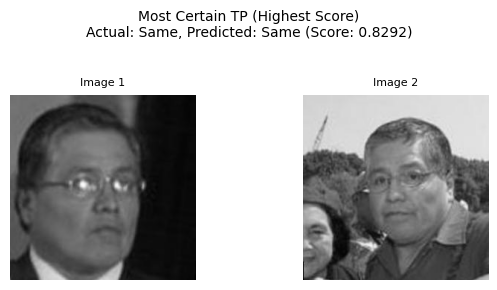

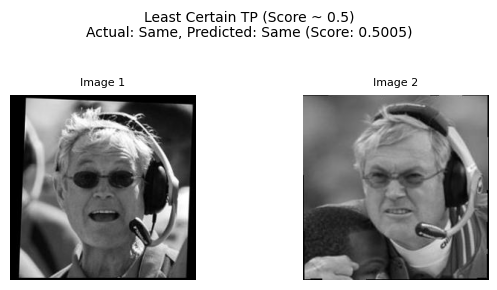


--- [TN] Correct Classifications (Different People) ---


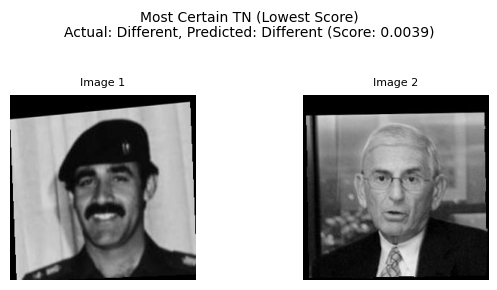

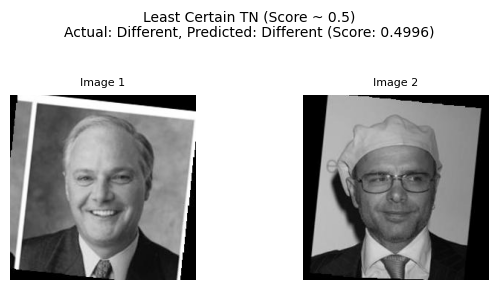


--- [FP] Misclassifications (Predicted Same, Actual Different) ---


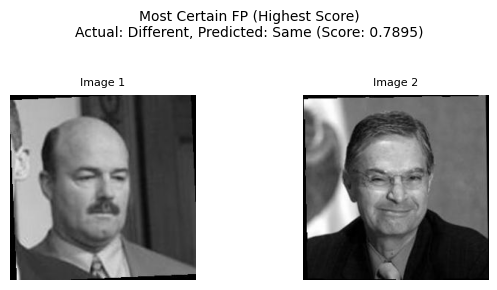

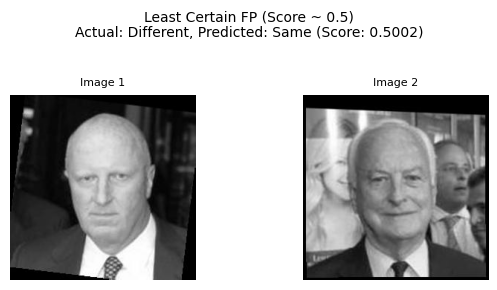


--- [FN] Misclassifications (Predicted Different, Actual Same) ---


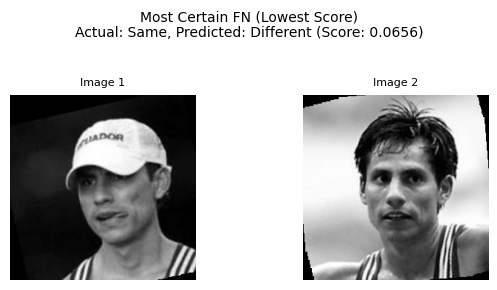

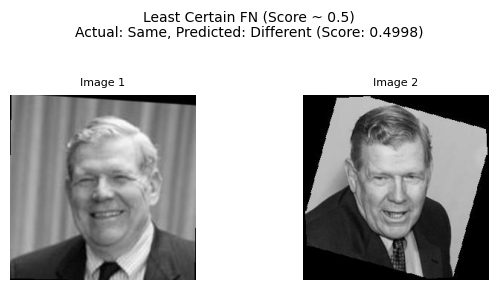

In [16]:

model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.to(DEVICE)
model.eval()  # Set model to evaluation mode

# True Positives (Actual=1, Pred=1)
tp_most_certain = None  # Highest score (closest to 1)
tp_least_certain = None  # Score closest to 0.5 (from above)
tp_max_score = -1.0
tp_min_uncertainty_above_threshold = float('inf')

# True Negatives (Actual=0, Pred=0)
tn_most_certain = None  # Lowest score (closest to 0)
tn_least_certain = None  # Score closest to 0.5 (from below)
tn_min_score = float('inf')
tn_min_uncertainty_below_threshold = float('inf')

# False Positives (Actual=0, Pred=1)
fp_most_certain = None  # Highest score (closest to 1)
fp_least_certain = None  # Score closest to 0.5 (from above)
fp_max_score = -1.0
fp_min_uncertainty_above_threshold = float('inf')

# False Negatives (Actual=1, Pred=0)
fn_most_certain = None  # Lowest score (closest to 0)
fn_least_certain = None  # Score closest to 0.5 (from below)
fn_min_score = float('inf')
fn_min_uncertainty_below_threshold = float('inf')

# Threshold for classification
threshold = 0.5

print(f"\nAnalyzing test set to find most/least certain examples...")

with torch.no_grad():
    processed_count = 0

    # Iterate through the entire test loader
    for i, (img1_batch, img2_batch, labels_batch) in enumerate(test_loader):
        img1_batch_dev, img2_batch_dev, labels_batch_dev = img1_batch.to(DEVICE), img2_batch.to(
            DEVICE), labels_batch.to(DEVICE)
        outputs = model(img1_batch_dev, img2_batch_dev)
        predicted_scores = outputs.squeeze()

        if predicted_scores.dim() == 0:
            predicted_scores = predicted_scores.unsqueeze(0)
        if labels_batch.dim() == 0:
            labels_batch = labels_batch.unsqueeze(0)

        predicted_labels = (predicted_scores >= threshold).float()

        # Check each item in the batch
        for j in range(labels_batch.size(0)):
            dataset_idx = processed_count
            processed_count += 1

            (img1_path, img2_path), _ = test_dataset.pairs[dataset_idx]

            # Get results for this item
            actual_label = int(labels_batch[j].item())
            pred_label = int(predicted_labels[j].item())
            score = predicted_scores[j].item()
            uncertainty = abs(score - threshold)  # How close the score is to the threshold

            example_data = (img1_path, img2_path, actual_label, pred_label, score)


            # Classify and update best examples

            # True Positive (Actual=1, Pred=1)
            if actual_label == 1 and pred_label == 1:
                # Most Certain TP (highest score)
                if score > tp_max_score:
                    tp_max_score = score
                    tp_most_certain = example_data
                # Least Certain TP (score closest to threshold from above)
                if uncertainty < tp_min_uncertainty_above_threshold:
                    tp_min_uncertainty_above_threshold = uncertainty
                    tp_least_certain = example_data

            # True Negative (Actual=0, Pred=0)
            elif actual_label == 0 and pred_label == 0:
                # Most Certain TN (lowest score)
                if score < tn_min_score:
                    tn_min_score = score
                    tn_most_certain = example_data
                # Least Certain TN (score closest to threshold from below)
                if uncertainty < tn_min_uncertainty_below_threshold:
                    tn_min_uncertainty_below_threshold = uncertainty
                    tn_least_certain = example_data

            # False Positive (Actual=0, Pred=1)
            elif actual_label == 0 and pred_label == 1:
                # Most Certain FP (highest score) - Model was confidently wrong
                if score > fp_max_score:
                    fp_max_score = score
                    fp_most_certain = example_data
                # Least Certain FP (score closest to threshold from above) - Model barely predicted wrong
                if uncertainty < fp_min_uncertainty_above_threshold:
                    fp_min_uncertainty_above_threshold = uncertainty
                    fp_least_certain = example_data

            # False Negative (Actual=1, Pred=0)
            elif actual_label == 1 and pred_label == 0:
                # Most Certain FN (lowest score) - Model was confidently wrong
                if score < fn_min_score:
                    fn_min_score = score
                    fn_most_certain = example_data
                # Least Certain FN (score closest to threshold from below) - Model barely predicted wrong
                if uncertainty < fn_min_uncertainty_below_threshold:
                    fn_min_uncertainty_below_threshold = uncertainty
                    fn_least_certain = example_data

print(f"Finished analyzing {processed_count} examples.")


def imshow_pair_from_path(img1_path, img2_path, title="Image Pair"):
    """Helper function to load and display a pair of images from file paths"""
    try:
        img1 = Image.open(img1_path).convert('RGB')
        img2 = Image.open(img2_path).convert('RGB')
    except FileNotFoundError:
        print(f"Error: Could not load image paths: {img1_path} or {img2_path}")
        return
    except Exception as e:
        print(f"Error loading images {img1_path}, {img2_path}: {e}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(img1)
    axes[0].set_title("Image 1", fontsize=8)
    axes[0].axis('off')
    axes[1].imshow(img2)
    axes[1].set_title("Image 2", fontsize=8)
    axes[1].axis('off')
    fig.suptitle(title, fontsize=10)
    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.show()


def display_single_example(example_data, title_prefix):
    if example_data is None:
        print(f"{title_prefix}: No example found.")
        return

    img1_path, img2_path, actual, pred, score = example_data
    actual_text = "Same" if actual == 1 else "Different"
    pred_text = "Same" if pred == 1 else "Different"
    title = f"{title_prefix}\nActual: {actual_text}, Predicted: {pred_text} (Score: {score:.4f})"
    imshow_pair_from_path(img1_path, img2_path, title=title)


print("\n--- Displaying Specific Examples ---")

print("\n--- [TP] Correct Classifications (Same Person) ---")
display_single_example(tp_most_certain, "Most Certain TP (Highest Score)")
display_single_example(tp_least_certain, "Least Certain TP (Score ~ 0.5)")
print("\n--- [TN] Correct Classifications (Different People) ---")
display_single_example(tn_most_certain, "Most Certain TN (Lowest Score)")
display_single_example(tn_least_certain, "Least Certain TN (Score ~ 0.5)")
print("\n--- [FP] Misclassifications (Predicted Same, Actual Different) ---")
display_single_example(fp_most_certain, "Most Certain FP (Highest Score)")
display_single_example(fp_least_certain, "Least Certain FP (Score ~ 0.5)")
print("\n--- [FN] Misclassifications (Predicted Different, Actual Same) ---")
display_single_example(fn_most_certain, "Most Certain FN (Lowest Score)")
display_single_example(fn_least_certain, "Least Certain FN (Score ~ 0.5)")



## 10. Results and Visualization

### 10.1. Plot Training and Validation Loss

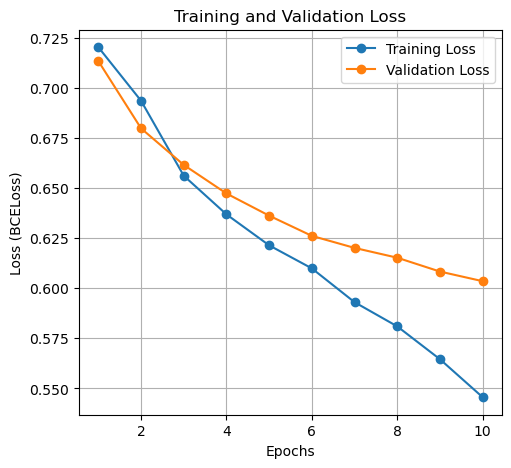

In [128]:
# Plot Training and Validation Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss (BCELoss)')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

### 10.2. Plot Training and Validation Accuracy

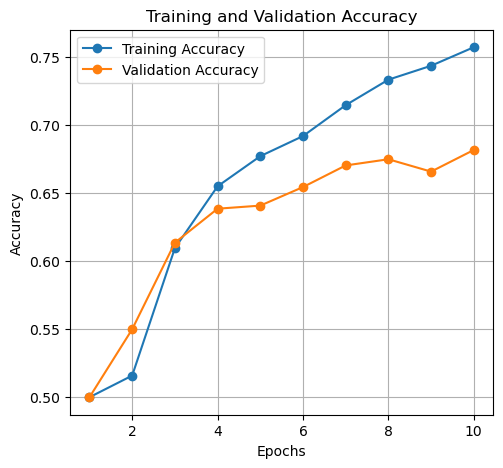

In [129]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_EPOCHS + 1), train_accuracies, label='Training Accuracy', marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), val_accuracies, label='Validation Accuracy', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
